# Lux on the Willett all-missions RGB dataset

Same dataset as `AnniesLasso/notebooks/train_rgb_wilett_all_missions.ipynb` -- the Willett
asteroseismic-age sample across Kepler + K2 + TESS, with identical quality cuts, the same
`thecannon` continuum normalization, and the RGB selection that notebook persists to
`rgb_selection_all_missions.parquet` -- but trained with the `LuxModel` API instead of the
Cannon.

Labels (one-step model, age fit directly from the spectra): Teff, logg, [Fe/H], [Mg/Fe],
[C/N], log10(age_L).

To (re)generate the RGB selection file (seismic EvoState + evolutionary-state classifier),
run the AnniesLasso notebook first.

In [1]:
# Play nicely with other notebook kernels on the same GPU: by default JAX
# preallocates ~75% of the card at first use and holds it for the kernel's
# lifetime, so a second kernel gets the scraps and dies with
# CUDA_ERROR_OUT_OF_MEMORY. Allocating on demand instead MUST be set before
# jax is imported.
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")

# JAX backend selection with CPU fallback: a tiny matmul probes whether the
# GPU backend can actually COMPILE (device discovery alone doesn't catch a
# broken CuDNN -- version-mismatch errors only surface at compile time).
import jax
import jax.numpy as jnp

try:
    (jnp.ones((8, 8)) @ jnp.ones((8, 8))).block_until_ready()
    print("JAX backend:", jax.default_backend())
except Exception as exc:
    print(f"GPU compile failed ({type(exc).__name__}) -- falling back to CPU")
    jax.config.update("jax_default_device", jax.devices("cpu")[0])
    (jnp.ones((8, 8)) @ jnp.ones((8, 8))).block_until_ready()
    print("JAX backend: CPU (fallback)")

JAX backend: gpu


Check overlap of stars Kepler K2 etc. 

In [2]:
import sys
from pathlib import Path

# make Lux/src importable both locally and on Gadi
for cand in ['../src', '/scratch/mk27/mj8805/Lux/src']:
    if os.path.exists(os.path.join(cand, 'lux_model.py')):
        sys.path.append(os.path.abspath(cand))
        break
else:
    raise FileNotFoundError('could not locate Lux/src -- adjust the candidate paths above')

# thecannon is used only for its continuum module, so the normalization is
# identical to the AnniesLasso notebook that defines this dataset
for cand in ['../../AnniesLasso', '/scratch/mk27/mj8805/AnniesLasso']:
    if os.path.exists(os.path.join(cand, 'thecannon', 'continuum.py')):
        sys.path.append(os.path.abspath(cand))
        break
else:
    raise FileNotFoundError('could not locate AnniesLasso (needed for thecannon.continuum)')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lux_model import LuxModel
from thecannon import continuum

plt.rcParams['figure.dpi'] = 110

# data root (Gadi first, then a local checkout if you have one)
for cand in ['/home/100/mj8805/scr_mk27', os.path.expanduser('~/scr_mk27')]:
    if os.path.exists(os.path.join(cand, 'bulge-ages-and-orbits', 'data')):
        SRC = Path(cand)
        break
else:
    raise FileNotFoundError('could not locate the bulge-ages-and-orbits data root')
print('data root:', SRC)

data root: /home/100/mj8805/scr_mk27


In [3]:
spectra = pd.read_parquet(SRC / 'bulge-ages-and-orbits/data/merged_with_ages_raw.parquet')

# ALL missions (Kepler + K2 + TESS). Only require a finite Willett age here;
# the RGB selection (seismic EvoState for Kepler, classifier for the rest) is
# reused from the AnniesLasso notebook further down.
spectra = spectra[np.isfinite(spectra['age_L'])].reset_index(drop=True)
spectra['log_age_L'] = np.log10(spectra['age_L'])
print(spectra['source'].value_counts().to_string())
print(len(spectra), 'stars with a finite Willett age')

source
Kepler    9809
K2        9196
TESS      1803
20808 stars with a finite Willett age


Add intrinsic scatter on the labels

In [4]:
# Abundance ratios used by the labels and the quality cuts, plus propagated
# errors (uncorrelated approximation).
if 'mg_fe' not in spectra.columns:
    spectra['mg_fe'] = spectra['raw_mg_h'] - spectra['raw_fe_h']
spectra['e_mg_fe'] = np.sqrt(spectra['raw_e_mg_h']**2 + spectra['raw_e_fe_h']**2)

spectra['c_n'] = spectra['raw_c_h'] - spectra['raw_n_h']
spectra['c_n_err'] = np.sqrt(spectra['raw_e_c_h']**2 + spectra['raw_e_n_h']**2)

# log-age error from the 16th/84th percentiles of the Willett posterior
spectra['e_log_age_L'] = 0.5 * (np.log10(spectra['age_84_L'])
                                - np.log10(spectra['age_16_L']))

In [5]:
# Training-set quality cuts, identical to train_rgb_wilett_all_missions.ipynb:
#
# 1) ASPCAP sentinel rows (-999.999): isfinite() does NOT catch them, and
#    c_n = -999.999 - (-999.999) = 0 looks normal, so they would sit in the
#    training set as enormous leverage points.
# 2) RelAge_L is the Willett catalogue's age-reliability flag; stars with an
#    unreliable reference age teach the model noise.
# 3) Young alpha-rich impostors: seismically young (age_L < 4 Gyr) but
#    alpha-rich (mg_fe > 0.15) stars with old-like chemistry (c_n > -0.2)
#    are predominantly mass-transfer/merger products whose reference ages
#    are wrong in exactly the way that hurts most: they teach the model that
#    old-looking spectra can be young.
n0 = len(spectra)

SENTINEL_COLS = ['raw_teff', 'raw_logg', 'raw_fe_h', 'raw_mg_h',
                 'raw_c_h', 'raw_n_h', 'raw_al_h']
sentinel = (spectra[SENTINEL_COLS] < -100).any(axis=1)
unreliable_age = ~spectra['RelAge_L'].astype(bool)
impostor = ((spectra['age_L'] < 4) & (spectra['mg_fe'] > 0.15)
            & (spectra['c_n'] > -0.2))

drop = sentinel | unreliable_age | impostor
print(f"sentinel labels: {sentinel.sum()}  |  RelAge_L=False: "
      f"{unreliable_age.sum()}  |  young alpha-rich impostors: "
      f"{impostor.sum()}  (categories overlap)")
spectra = spectra[~drop].reset_index(drop=True)
print(f"dropped {drop.sum()} of {n0} stars; {len(spectra)} remain")

sentinel labels: 54  |  RelAge_L=False: 4642  |  young alpha-rich impostors: 236  (categories overlap)
dropped 4833 of 20808 stars; 15975 remain


In [6]:
# LABELS: same as the one-step Cannon model -- age is fit directly alongside
# the atmospheric parameters, and c_n is kept in the vector (INCLUDE_C_N=True
# in the source notebook). Lux also needs per-label errors for the 1/err^2
# training weights.
LABEL_COLS = ['raw_teff', 'raw_logg', 'raw_fe_h', 'mg_fe', 'c_n', 'log_age_L']
ERR_COLS = ['raw_e_teff', 'raw_e_logg', 'raw_e_fe_h', 'e_mg_fe', 'c_n_err',
            'e_log_age_L']
missing_cols = [c for c in LABEL_COLS + ERR_COLS if c not in spectra.columns]
assert not missing_cols, f'missing columns: {missing_cols}'

# The wavelength/flux/ivar columns hold one array PER ROW; stack them into a
# 1-D dispersion and 2-D (n_stars, n_pixels) arrays, dropping any row whose
# arrays do not match the grid.
def to_array(x):
    if isinstance(x, str):                       # stringified list (e.g. from CSV)
        return np.array(x.strip('[] \n').split(','), dtype=float)
    arr = np.asarray(x, dtype=float)
    return arr[None] if arr.ndim == 0 else arr

dispersion = to_array(spectra['wavelength'].iloc[0])           # (n_pixels,)

flux_arrays, ivar_arrays, bad_rows = [], [], set()
for i, (fx, iv) in enumerate(zip(spectra['flux'], spectra['ivar'])):
    f_arr, iv_arr = to_array(fx), to_array(iv)
    if f_arr.size != dispersion.size or iv_arr.size != dispersion.size:
        bad_rows.add(i)
    flux_arrays.append(f_arr)
    ivar_arrays.append(iv_arr)

if bad_rows:
    print(f'dropping {len(bad_rows)} rows with flux/ivar arrays of the wrong size')
    keep_rows = [i for i in range(len(spectra)) if i not in bad_rows]
    spectra = spectra.iloc[keep_rows].reset_index(drop=True)
    flux_arrays = [a for i, a in enumerate(flux_arrays) if i not in bad_rows]
    ivar_arrays = [a for i, a in enumerate(ivar_arrays) if i not in bad_rows]

flux = np.vstack(flux_arrays)     # (n_stars, n_pixels)
ivar = np.vstack(ivar_arrays)     # (n_stars, n_pixels)

assert dispersion.ndim == 1, dispersion.shape
assert flux.shape == ivar.shape == (len(spectra), dispersion.size)
assert np.all(np.diff(dispersion) > 0), 'dispersion must be sorted ascending'
print(dispersion.shape, flux.shape, ivar.shape)

(8575,) (15975, 8575) (15975, 8575)


In [7]:
# Continuum normalization, identical to the AnniesLasso notebook: same
# continuum pixel list, region boundaries, and sinusoid parameters.
continuum_pixels = np.loadtxt(SRC / 'bulge-ages-and-orbits/data/continuum.list',
                              dtype=int, comments='#')
continuum_pixels = continuum_pixels[continuum_pixels < dispersion.size]
APOGEE_REGIONS = ([15090, 15822], [15823, 16451], [16452, 16971])

normalized_flux, normalized_ivar, continuum_fit, metadata = continuum.normalize(
    jnp.array(dispersion),
    jnp.array(flux),
    jnp.array(ivar),
    jnp.array(continuum_pixels),
    L=1400, order=3,
    regions=[jnp.array(r) for r in APOGEE_REGIONS],
)
normalized_flux = np.asarray(normalized_flux)
normalized_ivar = np.asarray(normalized_ivar)

good = ivar > 0
print('median raw flux on good pixels:    ', np.median(flux[good]))
print('median normalized flux (should ~1):', np.median(normalized_flux[good]))

Normalizing:   0%|          | 0/3 [00:00<?, ?region/s]

median raw flux on good pixels:     1176.0731201171875
median normalized flux (should ~1): 0.9832714979008085


In [8]:
# RGB selection: reuse the seismic + classifier selection persisted by the
# AnniesLasso notebook (that is exactly what the file was saved for), instead
# of re-running the evolutionary-state classifier here. A left merge on
# (APOGEE_ID, source), validated many-to-one, preserves row order and count,
# so `spectra` stays positionally aligned with the stacked flux arrays.
sel = pd.read_parquet(SRC / 'bulge-ages-and-orbits/data/rgb_selection_all_missions.parquet')
sel = sel[['APOGEE_ID', 'source', 'evo_state_source', 'rgb_proba']].drop_duplicates(
    subset=['APOGEE_ID', 'source'])
spectra = spectra.merge(sel, on=['APOGEE_ID', 'source'], how='left',
                        validate='many_to_one')
is_rgb = spectra['evo_state_source'].notna().to_numpy()

spectra = spectra[is_rgb].reset_index(drop=True)
normalized_flux = normalized_flux[is_rgb]
normalized_ivar = normalized_ivar[is_rgb]
n_seismic = (spectra['evo_state_source'] == 'seismic').sum()
n_classified = (spectra['evo_state_source'] == 'classified').sum()
print(f'{len(spectra)} RGB stars enter training '
      f'({n_seismic} seismic, {n_classified} classified)')

7783 RGB stars enter training (3434 seismic, 4349 classified)


make sure the model is inferring the spectra well - plot alpha iron plane, kiel diagtram, etc

once we have ages, take derivative of spectra with respect of labels - see where the model learns the age from

(alpha)mg/mn (iron) plane to filter halo out

In [9]:
# Drop stars with any non-finite label (mirrors the finite cut in the
# AnniesLasso notebook -- NaNs would break the fits).
finite = np.isfinite(spectra[LABEL_COLS].values).all(axis=1)
spectra = spectra[finite].reset_index(drop=True)
normalized_flux = normalized_flux[finite]
normalized_ivar = normalized_ivar[finite]
print(f'{(~finite).sum()} stars dropped for non-finite labels; {len(spectra)} remain')

# Lux flux inputs. Same sentinel convention as load_data.load_spectra and
# example-lux-api.ipynb: bad pixels (zero/negative ivar) get flux=1, err=9999.
bad_pix = ~(normalized_ivar > 0)
safe_ivar = np.where(bad_pix, 1., normalized_ivar)
fluxes = jnp.array(np.where(bad_pix, 1., normalized_flux))
fluxes_err = jnp.array(np.where(bad_pix, 9999., 1. / np.sqrt(safe_ivar)))
wl = jnp.array(dispersion)

# ASPCAP formal errors are internal precisions far below the true accuracy,
# so floor each label's error at a realistic literature value before it
# becomes the 1/err^2 training weight (mirrors load_data.ERR_FLOOR; the c_n
# floor is the quadrature sum of the C and N floors). Missing-label 9999
# sentinels are preserved so absent labels stay effectively unweighted.
err_floor = {
    'raw_teff': 30., 'raw_logg': 0.05, 'raw_fe_h': 0.03,
    'mg_fe': 0.03, 'c_n': 0.07, 'log_age_L': 0.05,
}

labels = jnp.array(spectra[LABEL_COLS].values)
labels_err_np = np.array(spectra[ERR_COLS].values, dtype=float)
missing = ~(labels_err_np > 0)     # <=0, NaN, inf -> missing-label sentinel
floor_vec = np.array([err_floor[n] for n in LABEL_COLS])
labels_err_np = np.maximum(labels_err_np, floor_vec)
labels_err_np[missing] = 9999.
labels_err = jnp.array(labels_err_np)

print(f'{fluxes.shape[0]} stars, {fluxes.shape[1]} pixels, '
      f'bad pixel fraction: {bad_pix.mean():.3f}')

182 stars dropped for non-finite labels; 7601 remain
7601 stars, 8575 pixels, bad pixel fraction: 0.090


## Train the model

Same `LuxModel` recipe as `example-lux-api.ipynb`: an 80/20 train/test split, a
reliable-pixel mask, `P = 256`, and the regularised scatter agenda. Cross-validate `P` and
the l2 strength properly with `src/run_kfold.py`.

In [10]:
# Train/test split and a reliable-pixel mask. Each pixel's beta is fit only
# from the stars where that pixel is unmasked; at the APOGEE chip gaps/edges
# that is a handful of stars against P latent dimensions, so those betas
# overfit and blow up (spikes in predict_fluxes). A near-100% cut is needed
# because a single chip-boundary pixel passing a looser cut still has a
# poorly-constrained beta.
from sklearn.model_selection import train_test_split

train_mask, test_mask = train_test_split(np.arange(labels.shape[0]),
                                         test_size=0.2, random_state=42)

good_frac = (np.asarray(fluxes_err[train_mask]) < 100).mean(axis=0)
keep = good_frac > 0.99
fluxes = fluxes[:, keep]
fluxes_err = fluxes_err[:, keep]
wl = wl[keep]
print(f'keeping {int(keep.sum())}/{keep.size} pixels ({100 * keep.mean():.1f}%); '
      f'dropping {int((~keep).sum())} thin pixels')

keeping 6934/8575 pixels (80.9%); dropping 1641 thin pixels


probably doesnt need to regularize that much

plot z as a function of labels if P very big - most will be zeros! try with smaller

In [12]:
LABEL_NAMES = list(LABEL_COLS)
model = LuxModel(P=128)
model.fit(labels[train_mask], labels_err[train_mask],
          fluxes[train_mask], fluxes_err[train_mask],
          n_iterations=1000, l2_reg_strength=1000, label_names=LABEL_NAMES)

iteration 1/1000: chi2 = 530325047.1264 (improvement 123321549.3742)
iteration 2/1000: chi2 = 147235186.2360 (improvement 87115818.6214)
iteration 3/1000: chi2 = 117913320.2087 (improvement 7150513.7827)
iteration 4/1000: chi2 = 113151443.4946 (improvement 1683368.7769)
iteration 5/1000: chi2 = 111237027.9954 (improvement 801603.3807)
iteration 6/1000: chi2 = 110002646.4509 (improvement 582261.3337)
iteration 7/1000: chi2 = 109090887.4389 (improvement 366119.2816)
iteration 8/1000: chi2 = 108587677.0758 (improvement 229364.5719)
iteration 9/1000: chi2 = 108204566.8542 (improvement 180767.0481)
iteration 10/1000: chi2 = 107909466.6714 (improvement 136859.3590)
iteration 11/1000: chi2 = 107697433.9423 (improvement 96181.2973)
iteration 12/1000: chi2 = 107546321.1618 (improvement 69425.1222)
iteration 13/1000: chi2 = 107429374.1450 (improvement 55336.3240)
iteration 14/1000: chi2 = 107330753.6162 (improvement 47571.7711)
iteration 15/1000: chi2 = 107243997.7651 (improvement 42200.8990)
it

## Predict labels for the held-out stars

One-to-one comparison against the ASPCAP/Willett reference labels. The quoted bias and
scatter are robust statistics (median and 1.4826*MAD) over all finite points, matching how
the AnniesLasso notebook quotes its k-fold results.

Predictions come with per-star diagnostics that are retained in the persisted results:
formal label uncertainties propagated from the flux errors through the exact latent solve
(`Cov(l) = A (B^T W B)^{-1} A^T`), and the chi-squared of each star's synthesised spectrum
against the observed one under the same weights (plus the good-pixel count and the reduced
chi-squared).

In [13]:
# Predictions with per-star diagnostics. The test-time zetas solve the exact
# weighted normal equations (B^T W_n B) zeta_n = B^T W_n f_n with weights
# W_n = diag(1 / (err_n^2 + V)), V = exp(2 ln_noise) the trained per-pixel
# scatters (scatters.get_zetas_test_using_fluxes_direct). The estimator is
# linear in the fluxes, so its covariance is (B^T W_n B)^{-1} exactly, and
# with labels l = A zeta the formal label covariance is
# A (B^T W_n B)^{-1} A^T. chi2 is the weighted residual of the synthesised
# spectrum against the observed one under the same weights; bad pixels
# (err=9999) carry ~zero weight there and are excluded from the good-pixel
# count used for degrees of freedom.
def predict_labels_with_diagnostics(model, fluxes, fluxes_err, chunk=128):
    """
    Returns (labels_pred, labels_pred_err, spec_chi2, spec_n_good), sizes
    N x M, N x M, N, N. Chunked over stars: G is N x P x P and the batched
    (P x Lambda) @ (Lambda x P) products would not fit in memory whole.
    """
    labels_pred, zetas = model.predict_labels(fluxes, fluxes_err,
                                              return_zetas=True)
    betas, alphas = model.betas, model.alphas
    ln_noise = model.ln_noise_fluxes
    if ln_noise is None:
        ln_noise = jnp.full(betas.shape[0], -20.)   # no-scatter fallback
    V = jnp.exp(2. * ln_noise)

    n_stars, M, P = fluxes.shape[0], alphas.shape[0], model.P
    labels_pred_err = np.empty((n_stars, M))
    spec_chi2 = np.empty(n_stars)
    for s in range(0, n_stars, chunk):
        f, e = fluxes[s:s + chunk], fluxes_err[s:s + chunk]
        w = 1. / (e**2 + V[None, :])                             # n x Lambda
        resid = f - zetas[s:s + chunk] @ betas.T
        spec_chi2[s:s + chunk] = np.asarray(jnp.sum(w * resid**2, axis=1))
        G = (betas.T[None, :, :] * w[:, None, :]) @ betas        # n x P x P
        # same negligible ridge as scatters._anchored_solve, for stars whose
        # masked pixels leave a latent direction unconstrained
        eps = 1e-12 * jnp.trace(G, axis1=-2, axis2=-1)[:, None, None] / P
        G = G + eps * jnp.eye(P)
        X = jnp.linalg.solve(G, jnp.broadcast_to(alphas.T, (f.shape[0], P, M)))
        var = jnp.einsum('mp,npm->nm', alphas, X)                # diag(A G^-1 A^T)
        labels_pred_err[s:s + chunk] = np.asarray(jnp.sqrt(var))

    spec_n_good = np.asarray((np.asarray(fluxes_err) < 100).sum(axis=1))
    return np.asarray(labels_pred), labels_pred_err, spec_chi2, spec_n_good

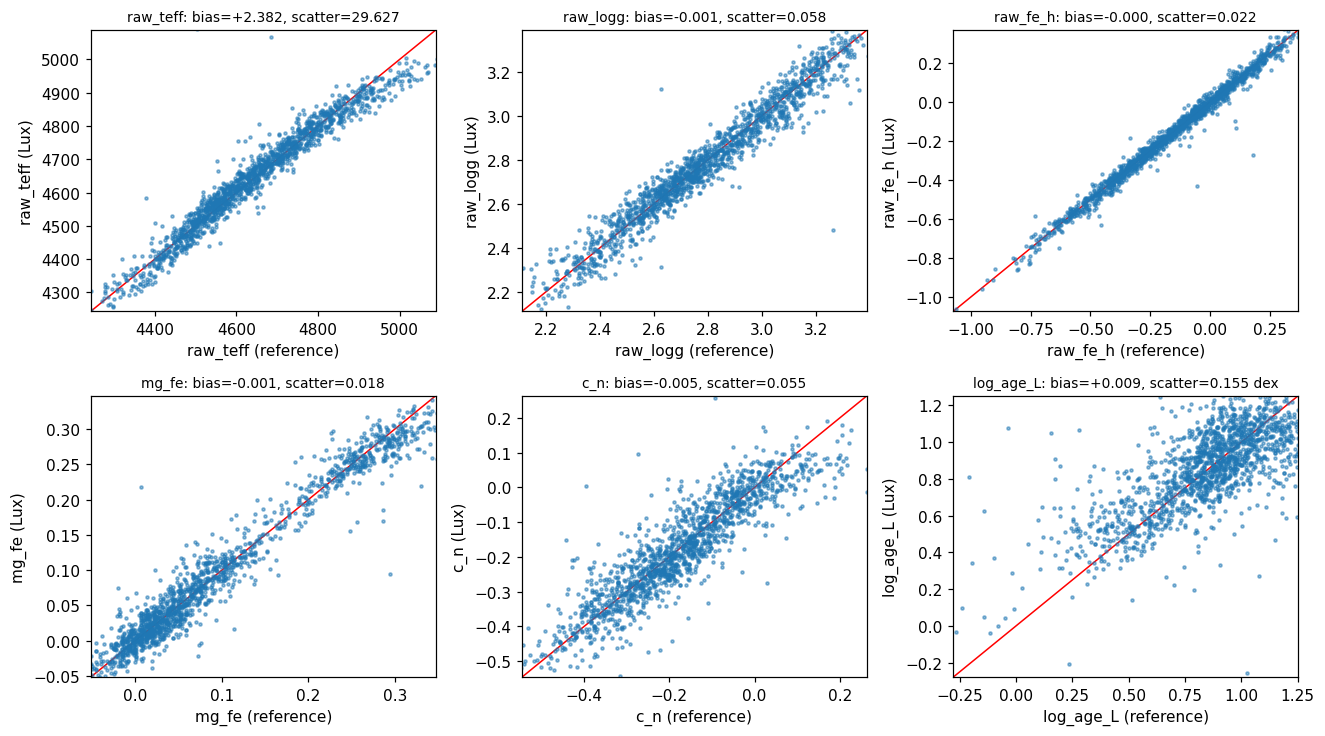

In [14]:
labels_pred, labels_pred_err, spec_chi2, spec_n_good = \
    predict_labels_with_diagnostics(model, fluxes[test_mask], fluxes_err[test_mask])
truth = np.asarray(labels[test_mask])

n_cols = 3
n_rows = int(np.ceil(len(LABEL_NAMES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.4 * n_rows))
axes = np.atleast_1d(axes).ravel()
for m, name in enumerate(LABEL_NAMES):
    ax = axes[m]
    x, y = truth[:, m], labels_pred[:, m]
    ok = np.isfinite(x) & np.isfinite(y)
    d = y[ok] - x[ok]
    bias = np.median(d)
    scatter = 1.4826 * np.median(np.abs(d - bias))   # robust sigma
    lims = [np.percentile(x[ok], 0.5), np.percentile(x[ok], 99.5)]
    ax.plot(lims, lims, 'r-', lw=1)
    ax.plot(x[ok], y[ok], '.', ms=4, alpha=0.5)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    unit = ' dex' if name == 'log_age_L' else ''
    ax.set_title(f'{name}: bias={bias:+.3f}, scatter={scatter:.3f}{unit}', fontsize=9)
    ax.set_xlabel(f'{name} (reference)')
    ax.set_ylabel(f'{name} (Lux)')
for ax in axes[len(LABEL_NAMES):]:
    ax.set_visible(False)
plt.tight_layout()

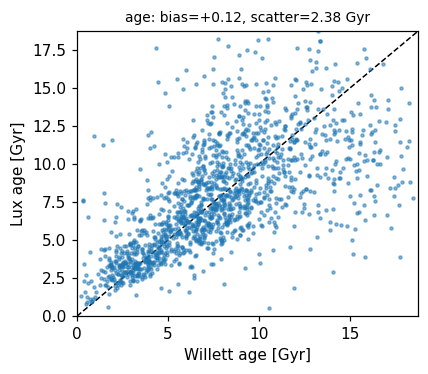

In [15]:
# the age panel above is in log10(age); show it back in linear Gyr
age_idx = LABEL_NAMES.index('log_age_L')
age_true = 10**truth[:, age_idx]
age_pred = 10**labels_pred[:, age_idx]
ok = np.isfinite(age_true) & np.isfinite(age_pred)

fig, ax = plt.subplots(figsize=(4, 3.5))
lims = [0., np.percentile(age_true[ok], 99.5) * 1.05]
ax.plot(lims, lims, 'k--', lw=1)
ax.plot(age_true[ok], age_pred[ok], '.', ms=4, alpha=0.5)
ax.set_xlim(lims)
ax.set_ylim(lims)
d = age_pred[ok] - age_true[ok]
bias = np.median(d)
scatter = 1.4826 * np.median(np.abs(d - bias))
ax.set_title(f'age: bias={bias:+.2f}, scatter={scatter:.2f} Gyr', fontsize=9)
ax.set_xlabel('Willett age [Gyr]')
ax.set_ylabel('Lux age [Gyr]')
plt.tight_layout()

In [16]:
# Numeric summary in native units (dex for log_age_L). scat/err ~ 1 means
# the model is as good as the labels can be trusted; >> 1 means real model
# error. (Scatter is measured against noisy reference labels, so model and
# reference noise add in quadrature.) "pred err" is the median formal
# prediction uncertainty propagated from the flux errors; it is a
# lower bound on the true error (it ignores model misspecification), so
# expect it below the observed scatter.
err_all = np.asarray(labels_err[test_mask])
print(f'{"label":>11}  {"bias":>9}  {"scatter":>9}  {"eff err":>9}  '
      f'{"scat/err":>8}  {"pred err":>9}')
for m, name in enumerate(LABEL_NAMES):
    d = labels_pred[:, m] - truth[:, m]
    d = d[np.isfinite(d)]
    bias = np.median(d)
    scatter = 1.4826 * np.median(np.abs(d - bias))
    good_err = err_all[:, m] < 9000    # drop 9999 sentinels from the median
    med_err = np.median(err_all[good_err, m]) if good_err.any() else np.nan
    eff_err = max(med_err, err_floor.get(name, 0.))
    med_perr = np.median(labels_pred_err[:, m])
    print(f'{name:>11}  {bias:>9.3g}  {scatter:>9.3g}  {eff_err:>9.3g}  '
          f'{scatter / eff_err:>8.2f}  {med_perr:>9.3g}')

# spectrum-fit quality: chi2 per degree of freedom (good pixels minus the P
# latent dims). ~1 means the flux errors + fitted scatters describe the
# residuals; a long tail flags stars the model cannot represent.
spec_rchi2 = spec_chi2 / (spec_n_good - model.P)
q = np.percentile(spec_rchi2, [16, 50, 84, 99])
print(f'\nspectrum reduced chi2 (test): median {q[1]:.3f}, '
      f'16/84% {q[0]:.3f}/{q[2]:.3f}, 99% {q[3]:.3f}')

      label       bias    scatter    eff err  scat/err   pred err
   raw_teff       2.38       29.6         30      0.99       9.68
   raw_logg  -0.000597     0.0579       0.05      1.16     0.0181
   raw_fe_h  -7.56e-05     0.0217       0.03      0.72    0.00658
      mg_fe  -0.000708     0.0182       0.03      0.61    0.00552
        c_n    -0.0049     0.0554       0.07      0.79     0.0123
  log_age_L    0.00897      0.155     0.0761      2.04     0.0328

spectrum reduced chi2 (test): median 0.974, 16/84% 0.768/1.324, 99% 8.031


In [17]:
# Save the trained model. Named *-all-missions so it cannot clobber other
# Lux models; LuxModel.load restores a model that predicts identically.
path = model.save('lux-model-rgb-wilett-all-missions.dill')
print('saved to', path)

saved to lux-model-rgb-wilett-all-missions.dill


In [18]:
# Persist per-star results for the systematics notebook
# (analyse-lux-systematics-rgb-all-missions.ipynb): reference labels and
# errors, Lux predictions for BOTH splits (train-set predictions expose
# overfitting when compared against test), the formal prediction
# uncertainties, the spectrum-fit chi2, and the metadata the systematics
# are sliced by (mission, selection channel, classifier probability, SNR).
labels_pred_train, labels_pred_err_train, spec_chi2_train, spec_n_good_train = \
    predict_labels_with_diagnostics(model, fluxes[train_mask], fluxes_err[train_mask])

META_COLS = [c for c in ('APOGEE_ID', 'source', 'evo_state_source',
                         'rgb_proba', 'EvoState', 'snr', 'snr_x', 'numax')
             if c in spectra.columns]
results = spectra[META_COLS + LABEL_COLS + ERR_COLS].copy()
results['split'] = ''
results.iloc[train_mask, results.columns.get_loc('split')] = 'train'
results.iloc[test_mask, results.columns.get_loc('split')] = 'test'

def fill_split_column(col, train_values, test_values):
    results[col] = np.nan
    loc = results.columns.get_loc(col)
    results.iloc[train_mask, loc] = train_values
    results.iloc[test_mask, loc] = test_values

for m, name in enumerate(LABEL_NAMES):
    fill_split_column(f'pred_{name}', labels_pred_train[:, m], labels_pred[:, m])
    fill_split_column(f'pred_err_{name}',
                      labels_pred_err_train[:, m], labels_pred_err[:, m])

# spectrum-fit quality under the inference weights (see the diagnostics
# helper); spec_rchi2 spends the P latent dims as fitted parameters
fill_split_column('spec_chi2', spec_chi2_train, spec_chi2)
fill_split_column('spec_n_pix', spec_n_good_train, spec_n_good)
results['spec_rchi2'] = results['spec_chi2'] / (results['spec_n_pix'] - model.P)

results_path = 'lux-results-rgb-wilett-all-missions.parquet'
results.to_parquet(results_path, index=False)
print(f'saved {len(results)} rows '
      f'({(results.split == "test").sum()} test, '
      f'{(results.split == "train").sum()} train) -> {results_path}')

saved 7601 rows (1521 test, 6080 train) -> lux-results-rgb-wilett-all-missions.parquet
